### Initialization and data preprocessing

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from rail_rl_env import RailNet, gurobi_minlp, gurobi_qp, qp_feasible, qp_feasible, gurobi_qp_presolve
from rail_rl_env import action_dict, d_pre, rho_whole, un, ul, uy, ua, ud, ur, depot, r_max, r_min, differ, Cmax, sigma, same, num_station, E_regular
from rail_rl_env import t_constant, h_min, tau_min, l_min, l_max, eta
from rail_fun import get_dict_min_max_state, preprocess_state, get_optimality_gap_cl, get_comparison, build_delta_vector, build_list_action#, get_optimality_gap_cl, build_stacke
import datetime
import matplotlib.pyplot as plt

N = 8
N_control = N-1
Env = RailNet(N)

#network parameters
num_actions = int(list(action_dict)[-1])+1 #index starts at 0
input_size=314

n_threads = 8

# dataset information for normalization and standardization
dict_min_max_state = get_dict_min_max_state(N)

In [2]:
class Network(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, lr, n_actions, batch_first=True):
        super(Network, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lr = lr
        self.n_actions = n_actions
        self.batch_first = batch_first        
        
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=batch_first)
        self.dense = nn.Linear(hidden_size, n_actions)
        
        # self.dropout = nn.Dropout(0.25)
        
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss = nn.MSELoss()
        
    def forward(self, input, h0, c0):
        
        # input = torch.randn(batch_size, seq_len, input_size)
        # h0 = torch.randn(num_layers, batch_size, hidden_size)
        # c0 = torch.randn(num_layers, batch_size, hidden_size)

        output, (hn, cn) = self.lstm(input, (h0, c0))
        
        # output = self.dropout(output)
        
        output = self.dense(output)
        # output = nn.ReLU()(output)
        # output = nn.Softmax(dim=2)(output)
        output = F.softmax(output, dim=2)

        return output

In [3]:
minlp_info_compressed = np.load('data_minlp//data_minlp_N08_0606.npy', allow_pickle=True)
N_datapoints = minlp_info_compressed.shape[0]

In [4]:
def decompress_minlp_info(minlp_info_compressed):
    
    state_n = minlp_info_compressed[0:28]    
    state_rho = minlp_info_compressed[28:28+28*9].reshape(9,28)    
    state_depot = minlp_info_compressed[28+28*9:28+28*9+14]    
    state_l = minlp_info_compressed[28+28*9+14:28+28*9+14+28*3].reshape(3,28)    
    delta_minlp = minlp_info_compressed[28+28*9+14+28*3:-1].reshape(N_control,8)    
    obj_val = minlp_info_compressed[-1]
    
    return state_n, state_rho, state_depot, state_l, delta_minlp, obj_val

stacked_states = np.zeros((N_datapoints,N_control,input_size))
stacked_labels = np.zeros((N_datapoints,N_control,num_actions))
stacked_obj_val = np.zeros((N_datapoints,))

stacked_list_actions = np.zeros((N_datapoints, N_control))

for j in range(N_datapoints):
    
    #input preprocessing
    
    state_n, state_rho, state_depot, state_l, delta_minlp, obj_val = decompress_minlp_info(minlp_info_compressed[j,:])
    
    stacked_states[j,0,:] = preprocess_state(state_n, state_rho, state_depot, state_l, dict_min_max_state)
    stacked_states[j,1:,:] = np.zeros((N_control-1, input_size))
    
    #label preprocessing

    idx_0 = j*np.ones(N_control, dtype=np.int32)
    idx_1 = np.arange(N_control)
    idx_2 = build_list_action(np.round(delta_minlp,2), N_control)
    idx_list = list(zip(idx_0, idx_1, idx_2))

    for k in range(N_control):
        stacked_labels[idx_list[k]] = 1
        
    stacked_obj_val[j] = obj_val
    
    stacked_list_actions[j] = idx_2 
        
def split_train_validation(stacked_states, stacked_labels, split_position=0.8):
    N_datapoints = stacked_states.shape[0]
    
    stacked_states_train = stacked_states[:int(np.ceil(N_datapoints*split_position))]
    stacked_labels_train = stacked_labels[:int(np.ceil(N_datapoints*split_position))]
    
    stacked_states_val = stacked_states[int(np.ceil(N_datapoints*split_position)):]
    stacked_labels_val = stacked_labels[int(np.ceil(N_datapoints*split_position)):]
    
    return stacked_states_train, stacked_labels_train, stacked_states_val, stacked_labels_val

stacked_states_train, stacked_labels_train, stacked_states_val, stacked_labels_val = split_train_validation(stacked_states, stacked_labels, split_position=0.8)

<BarContainer object of 143 artists>

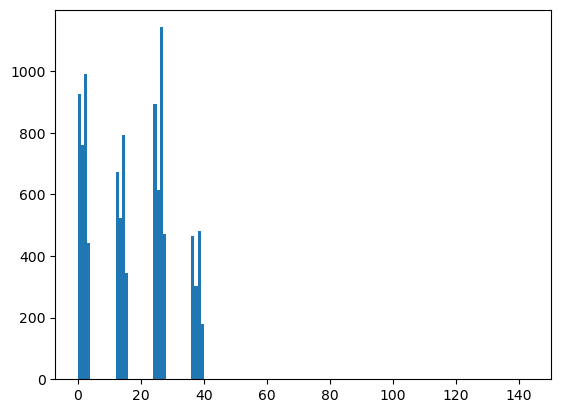

In [5]:
#frequency of optimal actions
plt.hist(stacked_list_actions[:,0], np.arange(144))[2]

### Training

In [6]:
hidden_size=128
num_layers=1
lr=1e-3

network = Network(input_size, hidden_size, num_layers, lr, num_actions)

batch_size=32 # 4 works well too
seq_len=N_control

In [7]:
# training
N_iter = 10000

loss_train = np.zeros((N_iter,1))
loss_val = []

h0 = torch.zeros(num_layers, batch_size, hidden_size)
c0 = torch.zeros(num_layers, batch_size, hidden_size)

for i in range(N_iter):
    
    network.train()

    batch = np.random.choice(stacked_states_train.shape[0], batch_size, replace=False)

    state_batch_train = torch.tensor(stacked_states_train[batch], dtype=torch.float32)
    labels_batch_train = torch.tensor(stacked_labels_train[batch], dtype=torch.float32)

    net_eval = network(state_batch_train, h0, c0)

    loss = network.loss(net_eval, labels_batch_train)
    
    loss_train[i] = loss.detach().numpy()

    network.zero_grad()        
    loss.backward()
    network.optimizer.step()
    
    #evaluation on validatation data
    if i % 1 == 0:
        with torch.no_grad():
            network.eval()
            batch = np.random.choice(stacked_states_val.shape[0], batch_size, replace=False)
            state_batch_val = torch.tensor(stacked_states_val[batch], dtype=torch.float32)
            labels_batch_val = torch.tensor(stacked_labels_val[batch], dtype=torch.float32)
            net_eval = network(state_batch_val, h0, c0)
            loss_val.append(network.loss(net_eval, labels_batch_val).detach().numpy())

In [8]:
def moving_average(a, n):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

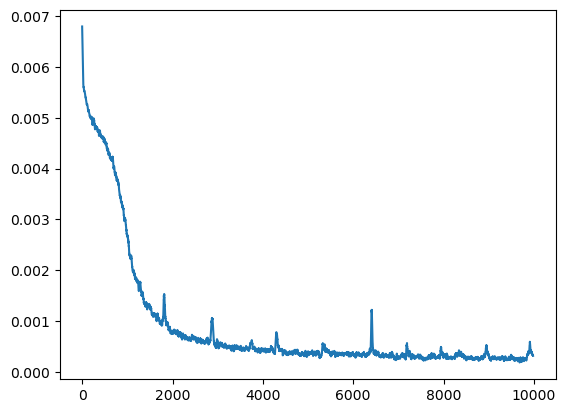

In [9]:
# loss_val = np.array(loss_val)

# adjust the length of the moving average window as needed
window_moving_average = 20

plt.plot(moving_average(loss_train,window_moving_average))
plt.show()

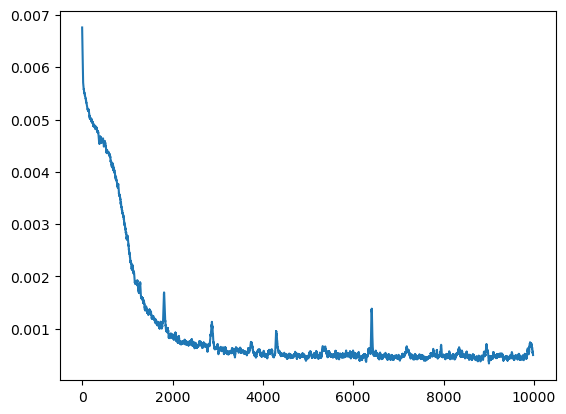

In [10]:
plt.plot(moving_average(loss_val,window_moving_average))
plt.show()

In [11]:
x = datetime.datetime.now()
date_str = '_%.2d_%.2d' %(x.day, x.month)
# torch.save(network.state_dict(), 'weights//railway_supervised2_%d_N%d'%(hidden_size, N) + date_str)

#### Testing the trained neural network

In [12]:
# this loads the pre-saved weights

input_size=314
hidden_size=128
num_layers=1
lr=1e-3
num_actions=int(list(action_dict)[-1])+1
network = Network(input_size, hidden_size, num_layers, lr, num_actions)
network.load_state_dict(torch.load('weights//railway_supervised_128_N8_07_06'))

<All keys matched successfully>

In [13]:
# open-loop comparison
N_iter = 10
idx_cntr_min = 35 #initial time of the day for random state
idx_ctnr_max = 60 #final time of the day for random state
time_lstm, time_minlp, cntr_infeasible, avg_cost_lstm, avg_cost_optimal, avg_cost_original = get_comparison(network, Env, N_control, N_iter, dict_min_max_state, idx_cntr_min, idx_ctnr_max, n_threads)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-25
min/mean/max times (learning): 0.158/0.967/3.755 sec
min/mean/max times (optimal): 1.595/4.985/15.278 sec
mean speed-up (learning is 5.15 times faster than optimal)

n_infeasible: 1.00 out of 10 points, infeasibility rate = 10.00 per cent

mean optimality gap of learning-based approach (open-loop) is 0.13 per cent
mean optimality gap of original approach (open-loop) is 9.38 per cent
average cost of optimal/learning/original approaches are 61824.67, 61903.33, 67622.81


In [14]:
#closed-loop comparison
N_episodes = 5
idx_cntr_min = 35 #initial time of the day for random state
idx_ctnr_max = 60 #final time of the day for random state
Env2 = RailNet(N)
list_a, list_d, list_l, list_n, list_n_after, list_stepcost = get_optimality_gap_cl(network, Env, Env2, N_control, N_episodes, dict_min_max_state,idx_cntr_min, idx_ctnr_max, n_threads)


n_infeasible: 2.00 out of 51 points, infeasibility rate = 3.92 per cent

mean optimality gap of learning-based approach (closed-loop) is 0.18 per cent
mean optimality gap of original approach (closed-loop) is 5.92 per cent
average cost of optimal/learning/original approaches are 3753.14, 3759.94, 3975.49


In [15]:
# prints the number of steps on each episode
for i in range(N_episodes):
    print(len(list_d[i]))

4
15
15
15
0


In [16]:
"""
This cell extracts all the trajectories from the output provided by the get_optimality_gap_cl function

ex: d = list_d[episode][step][opt][station]

"""

episode = 1 # change the episode number if the number of samples is not sufficient
opt = 0 # 0 for learning-based, 1 for optimal, 2 for original

a_learning = []
a_optimal = []
a_original = []

d_learning = []
d_optimal = []
d_original = []

l_learning = []
l_optimal = []
l_original = []

n_learning = []
n_optimal = []
n_original = []

n_after_learning = []
n_after_optimal = []
n_after_original = []

stepcost_learning = []
stepcost_optimal = []
stepcost_original = []

for step in range(len(list_d[episode])):
    
    a_learning.append(list_a[episode][step][0])
    a_optimal.append(list_a[episode][step][1])
    a_original.append(list_a[episode][step][2])
    
    d_learning.append(list_d[episode][step][0])
    d_optimal.append(list_d[episode][step][1])
    d_original.append(list_d[episode][step][2])
    
    l_learning.append(list_l[episode][step][0])
    l_optimal.append(list_l[episode][step][1])
    l_original.append(list_l[episode][step][2])
    
    n_learning.append(list_n[episode][step][0])
    n_optimal.append(list_n[episode][step][1])
    n_original.append(list_n[episode][step][2])
    
    n_after_learning.append(list_n_after[episode][step][0])
    n_after_optimal.append(list_n_after[episode][step][1])
    n_after_original.append(list_n_after[episode][step][2])
    
    stepcost_learning.append(list_stepcost[episode][step][0])
    stepcost_optimal.append(list_stepcost[episode][step][1])
    stepcost_original.append(list_stepcost[episode][step][2])
    
a_learning = np.array(a_learning)
a_optimal = np.array(a_optimal)
a_original = np.array(a_original)    
    
d_learning = np.array(d_learning)
d_optimal = np.array(d_optimal)
d_original = np.array(d_original)

l_learning = np.array(l_learning)
l_optimal = np.array(l_optimal)
l_original = np.array(l_original)

n_learning = np.array(n_learning)
n_optimal = np.array(n_optimal)
n_original = np.array(n_original)

n_after_learning = np.array(n_after_learning)
n_after_optimal = np.array(n_after_optimal)
n_after_original = np.array(n_after_original)

stepcost_learning = np.array(stepcost_learning)
stepcost_optimal = np.array(stepcost_optimal)
stepcost_original = np.array(stepcost_original)

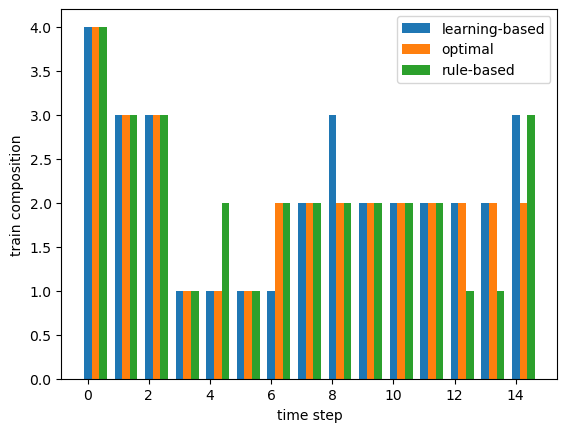

In [17]:
station = 5

x = np.arange(l_learning.shape[0])

plt.bar(x, l_learning[:,station], width=0.25, label='learning-based')
plt.bar(x+0.25, l_optimal[:,station], width=0.25, label='optimal')
plt.bar(x+0.5, l_original[:,station], width=0.25, label='rule-based')
plt.legend()
plt.xlabel('time step')
plt.ylabel('train composition')
plt.show()

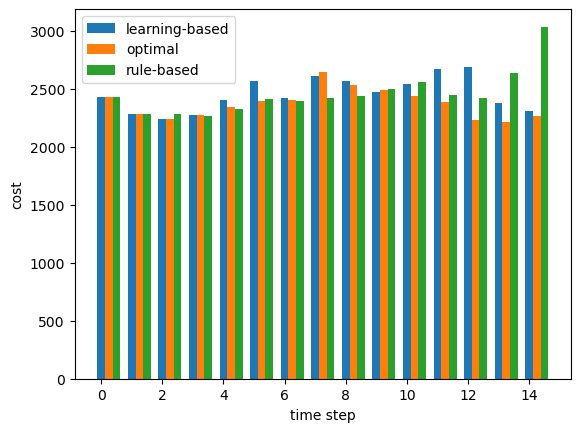

In [18]:
x = np.arange(len(stepcost_learning))

plt.bar(x, stepcost_learning, width=0.25, label='learning-based')
plt.bar(x+0.25, stepcost_optimal, width=0.25, label='optimal')
plt.bar(x+0.5, stepcost_original, width=0.25, label='rule-based')
plt.legend()
plt.xlabel('time step')
plt.ylabel('cost')
plt.show()

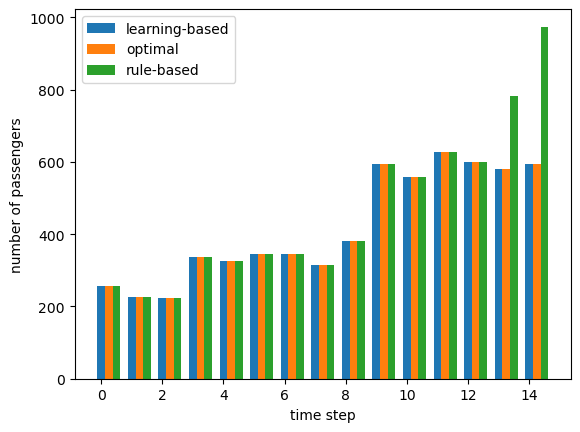

In [19]:
x = np.arange(n_learning.shape[0])

plt.bar(x, n_learning[:,station], width=0.25, label='learning-based')
plt.bar(x+0.25, n_optimal[:,station], width=0.25, label='optimal')
plt.bar(x+0.5, n_original[:,station], width=0.25, label='rule-based')
plt.legend()
plt.xlabel('time step')
plt.ylabel('number of passengers')
plt.show()

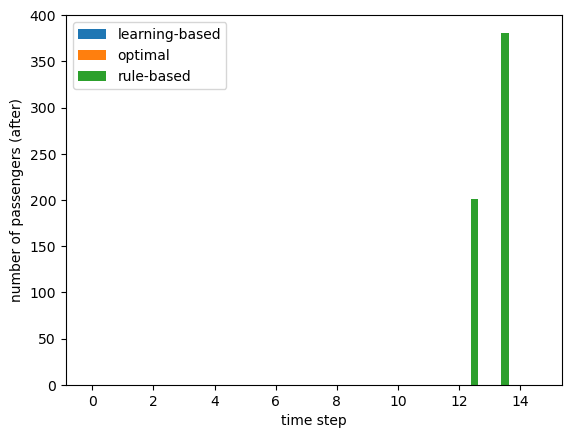

In [20]:
x = np.arange(n_learning.shape[0])

plt.bar(x, n_after_learning[:,station], width=0.25, label='learning-based')
plt.bar(x+0.25, n_after_optimal[:,station], width=0.25, label='optimal')
plt.bar(x+0.5, n_after_original[:,station], width=0.25, label='rule-based')
plt.legend()
plt.xlabel('time step')
plt.ylabel('number of passengers (after)')
plt.show()